# Entrenamiento de Modelos CNN — Plant Disease Classifier

Notebook  para entrenamiento **reproducible y comparable** de modelos Transfer Learning sobre clasificación binaria de enfermedades en plantas.

| Parámetro | Valor |
|-----------|-------|
| Problema | Clasificación binaria |
| Clases | `healthy = 0`, `diseased = 1` |
| Framework | TensorFlow / Keras |
| Input | 224×224×3 RGB |
| Split | 70% train / 15% val / 15% test |
| **Métrica prioritaria** | **Recall** (minimizar falsos negativos) |

### Modelos
- **DenseNet121** — Estrategia: Warm-up (fase 1 cabeza → fase 2 fine-tuning)
- **ResNet50** — Estrategia: Warm-up (fase 1 cabeza → fase 2 fine-tuning)

## 1. Imports y Configuración

In [32]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU"))} GPU(s)')
print(f'GPU devices: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.21.0
GPU disponible: 0 GPU(s)
GPU devices: []


## 2. Configuración Global y Seeds

In [49]:
# ============================================================
# SEEDS — Garantizar reproducibilidad
# ============================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# HIPERPARÁMETROS
# ============================================================
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 16

# DenseNet121 — Warm-up
DN_WARMUP_EPOCHS   = 8        # Fase 1: solo cabeza
DN_FINETUNE_EPOCHS = 5        # Fase 2: fine-tuning parcial
DN_WARMUP_LR       = 1e-3
DN_FINETUNE_LR     = 1e-5
DN_UNFREEZE_LAYERS = 20       # Últimas N capas a descongelar en DenseNet121

# ResNet50 — Warm-up
WARMUP_EPOCHS   = 8       # Fase 1: solo cabeza
FINETUNE_EPOCHS = 15       # Fase 2: fine-tuning parcial
WARMUP_LR       = 1e-3
FINETUNE_LR     = 1e-5
UNFREEZE_LAYERS = 50       # Últimas N capas a descongelar en ResNet50

# Callbacks
PATIENCE        = 8
MONITOR_METRIC  = 'val_recall'  # Priorizar recall
MONITOR_MODE    = 'max'

print('Configuración cargada:')
print(f'  IMG_SIZE:            {IMG_SIZE}')
print(f'  BATCH_SIZE:          {BATCH_SIZE}')
print(f'  MONITOR_METRIC:      {MONITOR_METRIC}')
print(f'  DN_WARMUP_LR:        {DN_WARMUP_LR}  |  DN_FINETUNE_LR: {DN_FINETUNE_LR}')
print(f'  WARMUP_LR:           {WARMUP_LR}  |  FINETUNE_LR: {FINETUNE_LR}')

Configuración cargada:
  IMG_SIZE:            (224, 224)
  BATCH_SIZE:          16
  MONITOR_METRIC:      val_recall
  DN_WARMUP_LR:        0.001  |  DN_FINETUNE_LR: 1e-05
  WARMUP_LR:           0.001  |  FINETUNE_LR: 1e-05


## 3. Paths del Proyecto

In [34]:
# ============================================================
# AUTO-DETECTAR RAÍZ DEL REPOSITORIO
# ============================================================
def find_repo_root(start: Path, marker: str = 'environment.yml') -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró '{marker}' en ningún directorio padre de {start}")

REPO_ROOT   = find_repo_root(Path().resolve())
SPLITS_DIR  = REPO_ROOT / 'data' / 'splits'
RESULTS_DIR = REPO_ROOT / 'reports' / 'results'

DENSENET_DIR   = RESULTS_DIR / 'densenet121'
DENSENET_PLOTS = DENSENET_DIR / 'plots'
RESNET_DIR     = RESULTS_DIR / 'resnet50'
RESNET_PLOTS   = RESNET_DIR / 'plots'

for d in [DENSENET_DIR, DENSENET_PLOTS, RESNET_DIR, RESNET_PLOTS]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Repo root:    {REPO_ROOT}')
print(f'Splits dir:   {SPLITS_DIR}')
print(f'Results dir:  {RESULTS_DIR}')
print()
print('Subcarpetas de resultados creadas:')
print(f'  {DENSENET_DIR}')
print(f'  {RESNET_DIR}')

Repo root:    /Users/antonioesparza/repos/GitHub/plant-disease-classifier
Splits dir:   /Users/antonioesparza/repos/GitHub/plant-disease-classifier/data/splits
Results dir:  /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results

Subcarpetas de resultados creadas:
  /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/densenet121
  /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/resnet50


## 4. Carga de Splits

In [35]:
# ============================================================
# CARGAR SPLITS DESDE data/splits/
# ============================================================
for split_file in ['train.csv', 'val.csv', 'test.csv']:
    path = SPLITS_DIR / split_file
    assert path.exists(), f'No se encontró: {path}. Ejecuta primero la celda de split del dataset.'

train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
val_df   = pd.read_csv(SPLITS_DIR / 'val.csv')
test_df  = pd.read_csv(SPLITS_DIR / 'test.csv')

# Asegurar tipos correctos para flow_from_dataframe con class_mode='raw'
for df in [train_df, val_df, test_df]:
    df['binary_label'] = df['binary_label'].astype(float)

# ============================================================
# DISTRIBUCIÓN DE CLASES
# ============================================================
total = len(train_df) + len(val_df) + len(test_df)
print('=' * 55)
print(f'{"Split":<15} {"Total":>8} {"Healthy":>10} {"Diseased":>10}')
print('=' * 55)
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    h = (df['binary_label'] == 0).sum()
    d = (df['binary_label'] == 1).sum()
    print(f'{name:<15} {len(df):>8} {h:>10} {d:>10}')
print('=' * 55)
print(f'{"TOTAL":<15} {total:>8}')
print()
print('Primeras filas del train split:')
train_df.head()

Split              Total    Healthy   Diseased
Train              14446       2255      12191
Validation          3096        483       2613
Test                3096        483       2613
TOTAL              20638

Primeras filas del train split:


,filepath,original_class,binary_label,binary_class
0,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_Bacterial_spot,1.0,diseased
1,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato__Target_Spot,1.0,diseased
2,/Users/antonioesparza/repos/GitHub/plant-disea...,Potato___Early_blight,1.0,diseased
3,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_Bacterial_spot,1.0,diseased
4,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_Spider_mites_Two_spotted_spider_mite,1.0,diseased


## 5. Data Generators

- **Train**: con data augmentation
- **Validation / Test**: sin augmentation
- Se usa `preprocessing_function` específico de cada modelo (NO `rescale=1./255`)

In [37]:
# ============================================================
# FUNCIÓN REUTILIZABLE PARA CREAR GENERADORES
# ============================================================
def create_generators(train_df, val_df, test_df, preprocess_fn,
                      batch_size=BATCH_SIZE, img_size=IMG_SIZE, seed=SEED):
    """
    Crea generadores train (con augmentation), val y test (sin augmentation).
    Usa class_mode='raw' para retornar labels numéricos directamente.
    """
    # Train: WITH augmentation
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.85, 1.15],
    )

    # Val / Test: WITHOUT augmentation
    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='binary_label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='raw',
        shuffle=True,
        seed=seed,
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='filepath',
        y_col='binary_label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='raw',
        shuffle=False,
    )

    test_gen = eval_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='binary_label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='raw',
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


# Crear generadores para DENSENET121
print('Creando generadores DenseNet121...')
dn_train_gen, dn_val_gen, dn_test_gen = create_generators(
    train_df, val_df, test_df, densenet_preprocess
)

print()
print(f'Train batches:      {len(dn_train_gen)}')
print(f'Validation batches: {len(dn_val_gen)}')
print(f'Test batches:       {len(dn_test_gen)}')
print(f'Batch shape (X):    {dn_train_gen[0][0].shape}')
print(f'Batch shape (y):    {dn_train_gen[0][1].shape}')
print()
print('Nota: Los generadores de ResNet50 se crean justo antes de su entrenamiento para optimizar memoria.')

Creando generadores DenseNet121...
Found 14446 validated image filenames.
Found 3096 validated image filenames.
Found 3096 validated image filenames.

Train batches:      903
Validation batches: 194
Test batches:       194
Batch shape (X):    (16, 224, 224, 3)
Batch shape (y):    (16,)

Nota: Los generadores de ResNet50 se crean justo antes de su entrenamiento para optimizar memoria.


## 6. Visualización de Batches

Found 16 validated image filenames belonging to 2 classes.


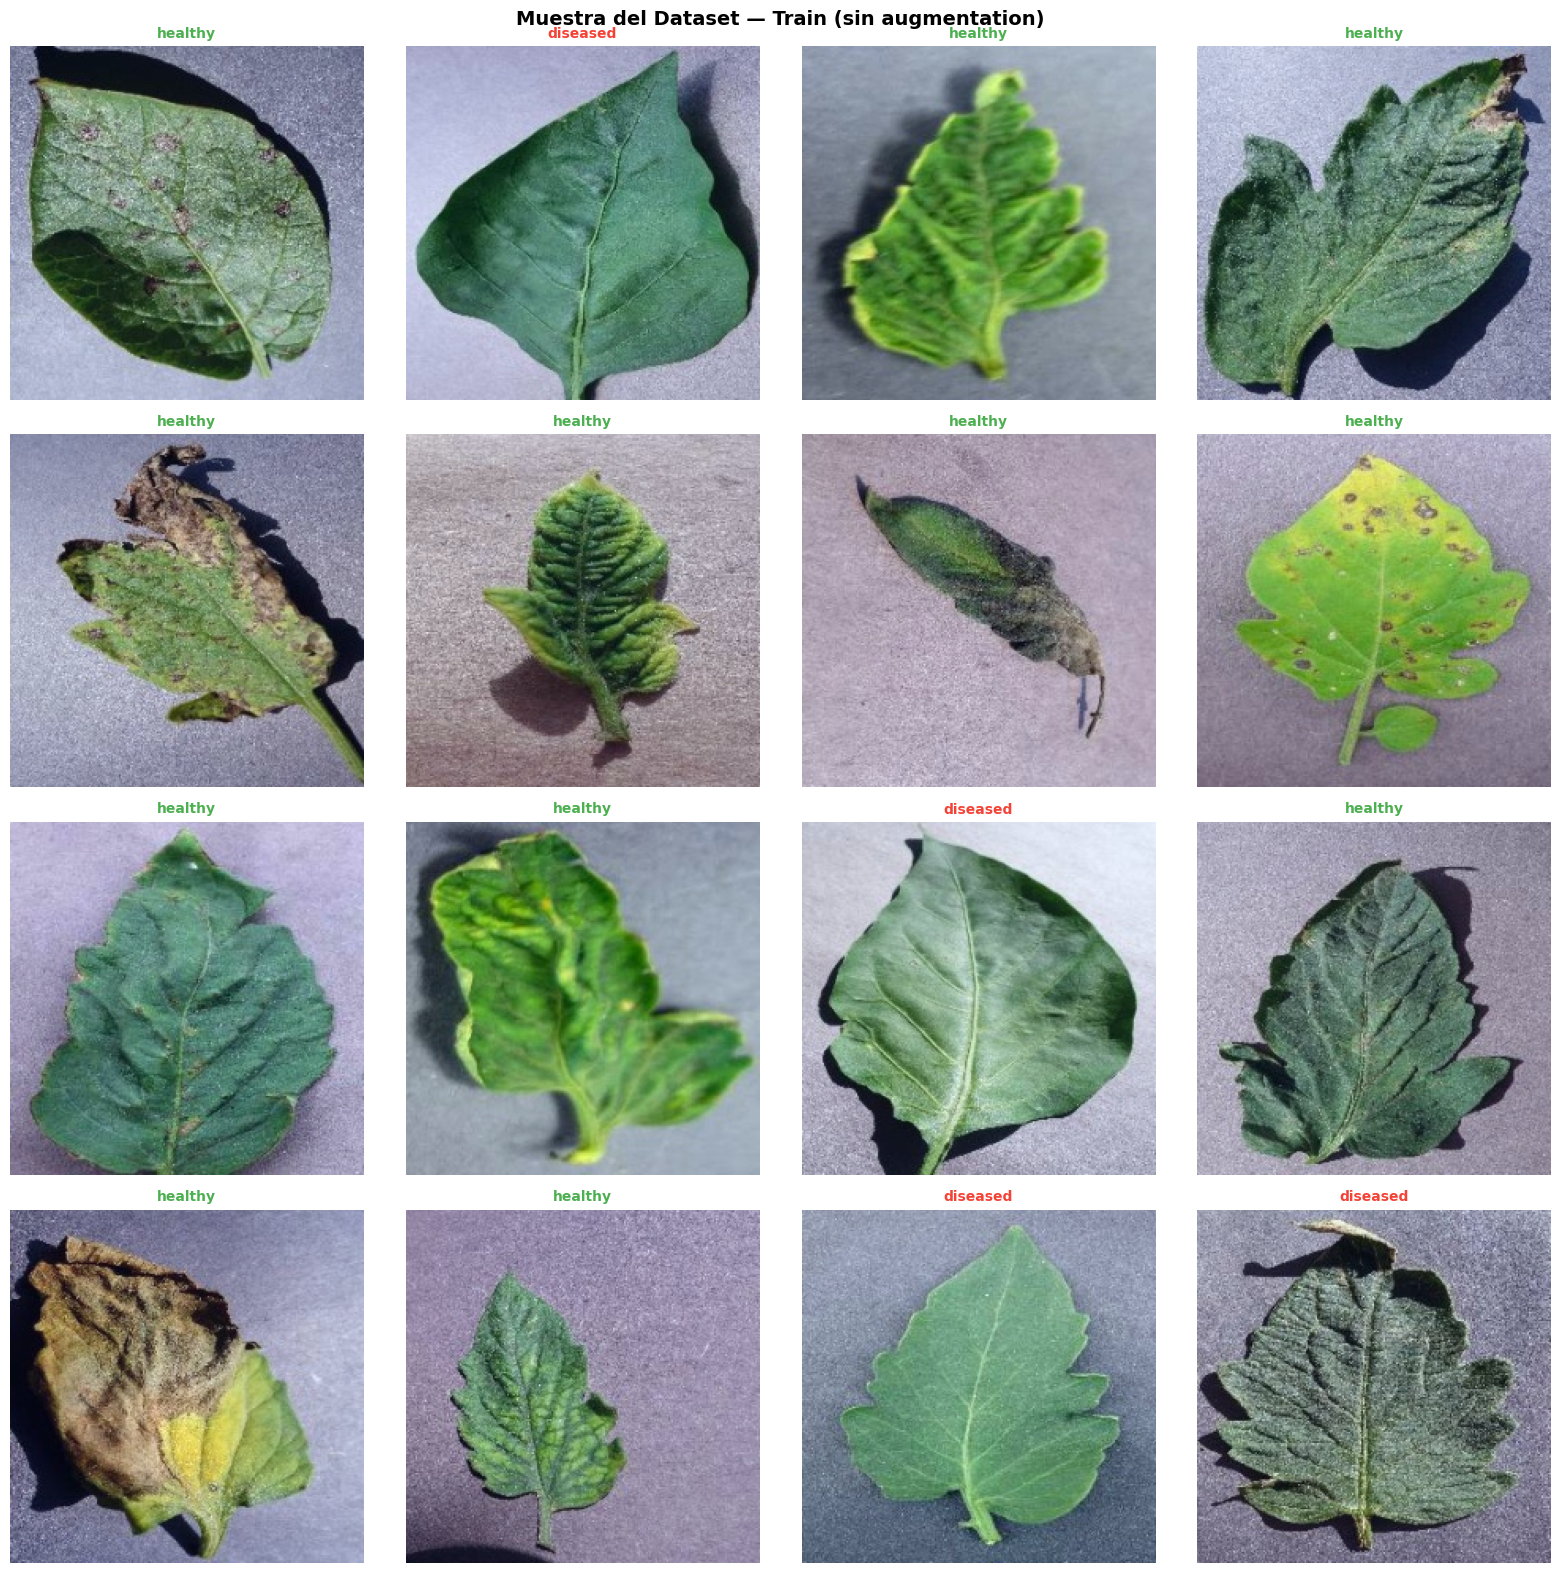

Figura guardada en reports/results/sample_images.png


In [38]:
# ============================================================
# VISUALIZAR IMÁGENES DE EJEMPLO (SIN AUGMENTATION)
# ============================================================
eval_datagen_vis = ImageDataGenerator(preprocessing_function=densenet_preprocess)
vis_gen = eval_datagen_vis.flow_from_dataframe(
    dataframe=train_df.sample(16, random_state=SEED),
    x_col='filepath',
    y_col='binary_class',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    shuffle=False,
)

batch_x, batch_y = next(vis_gen)
class_names = ['healthy', 'diseased']

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for idx, ax in enumerate(axes.flatten()):
    img = batch_x[idx]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    label_idx = int(batch_y[idx])
    color = '#4CAF50' if label_idx == 0 else '#F44336'
    ax.set_title(class_names[label_idx], fontsize=10, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('Muestra del Dataset — Train (sin augmentation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en reports/results/sample_images.png')

## 7. Class Weights

In [40]:
# ============================================================
# CLASS WEIGHTS — Balancear el costo de errores por clase
# ============================================================
y_train = train_df['binary_label'].astype(int).values
unique_classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train,
)
class_weights = dict(zip(unique_classes.tolist(), weights.tolist()))

print(f'Clases: {unique_classes}')
print(f'Class weights: {class_weights}')
print()
print(f'  healthy  (0): peso = {class_weights[0]:.4f}')
print(f'  diseased (1): peso = {class_weights[1]:.4f}')
print()
print('Nota: Peso mayor en la clase menos frecuente para penalizar más sus errores.')

Clases: [0 1]
Class weights: {0: 3.2031042128603104, 1: 0.5924862603560004}

  healthy  (0): peso = 3.2031
  diseased (1): peso = 0.5925

Nota: Peso mayor en la clase menos frecuente para penalizar más sus errores.


## 8. Métricas y Helpers

In [ ]:

# ============================================================
# MÉTRICA F1 PERSONALIZADA
# ============================================================
def f1_metric(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    y_pred = K.round(y_pred)
    tp = K.sum(y_true * y_pred, axis=0)
    fp = K.sum((1 - y_true) * y_pred, axis=0)
    fn = K.sum(y_true * (1 - y_pred), axis=0)
    precision = tp / (tp + fp + K.epsilon())
    recall    = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)


# ============================================================
# CALLBACKS
# ============================================================
def get_callbacks(model_name: str, out_dir: Path, monitor: str = MONITOR_METRIC, mode: str = MONITOR_MODE, patience: int = PATIENCE):
    return [
        EarlyStopping(
            monitor=monitor, mode=mode,
            patience=patience, restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor, mode=mode,
            factor=0.5, patience=4, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=str(out_dir / f'{model_name}_best.keras'),
            monitor=monitor, mode=mode,
            save_best_only=True, verbose=1
        ),
    ]


# ============================================================
# PLOT HISTORY
# ============================================================
def plot_history(history, title: str, out_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = [('loss', 'Loss'), ('recall', 'Recall'), ('precision', 'Precision')]
    for ax, (metric, label) in zip(axes, metrics):
        if metric in history:
            ax.plot(history[metric],      label='Train', linewidth=2)
            ax.plot(history[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
            ax.set_title(label, fontsize=13, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.legend()
            ax.grid(True, alpha=0.4)
    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada en: {out_path}')


# ============================================================
# EVALUATE MODEL
# ============================================================
def evaluate_model(model, test_gen, test_df, out_dir: Path, model_name: str):
    print(f'\n--- Evaluando {model_name} sobre test set ---')
    y_true  = test_df['binary_label'].astype(int).values
    y_probs = model.predict(test_gen, verbose=1)
    y_pred  = (y_probs.flatten() >= 0.5).astype(int)

    # Classification report
    report = classification_report(y_true, y_pred,
                                   target_names=['healthy', 'diseased'], output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(out_dir / 'classification_report.csv')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['healthy', 'diseased']))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=['healthy', 'diseased'],
                         columns=['pred_healthy', 'pred_diseased'])
    cm_df.to_csv(out_dir / 'confusion_matrix.csv')

    tn, fp, fn, tp = cm.ravel()
    cm_annot = np.array([
        [f'{tn}\n(Correcto)',          f'{fp}\nSanas clasificadas\ncomo enfermas'],
        [f'{fn}\nEnfermas clasificadas\ncomo sanas', f'{tp}\n(Correcto)'],
    ])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=cm_annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Pred: Sana', 'Pred: Enferma'],
                yticklabels=['Real: Sana', 'Real: Enferma'],
                annot_kws={'size': 10})
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Etiqueta Real', fontsize=12)
    ax.set_title(f'Matriz de Confusión — {model_name}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / 'plots' / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Resumen de métricas
    metrics = {
        'accuracy':          report['accuracy'],
        'precision_diseased': report['diseased']['precision'],
        'recall_diseased':    report['diseased']['recall'],
        'f1_diseased':        report['diseased']['f1-score'],
        'precision_healthy':  report['healthy']['precision'],
        'recall_healthy':     report['healthy']['recall'],
        'f1_healthy':         report['healthy']['f1-score'],
    }
    pd.DataFrame([metrics]).to_csv(out_dir / 'metrics.csv', index=False)
    return metrics


# ============================================================
# COMBINE HISTORIES (para warm-up)
# ============================================================
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined


print('Funciones auxiliares definidas: f1_metric, get_callbacks, plot_history, evaluate_model, combine_histories')


Funciones auxiliares definidas: f1_metric, get_callbacks, plot_history, evaluate_model, combine_histories


## 9. Modelo DenseNet121 — Warm-up

**Estrategia**: Entrenamiento en dos fases.

| Fase | Backbone | Learning Rate | Epochs |
|------|----------|--------------|--------|
| Fase 1 (Warm-up) | Congelado | 1e-3 | 8 |
| Fase 2 (Fine-tuning) | Últimas 40 capas desbloqueadas (BN congeladas) | 1e-5 | 15 |

**Arquitectura de la cabeza**:
```
GlobalAveragePooling2D  →  Dense(128, relu)  →  Dropout(0.4)  →  Dense(1, sigmoid)
```

In [42]:
# ============================================================
# CONSTRUIR DENSENET121
# ============================================================
def build_densenet121(img_size=IMG_SIZE, lr=DN_WARMUP_LR):
    """DenseNet121 — backbone congelado para Fase 1 (Warm-up)."""
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    base.trainable = False  # Congelado para Fase 1

    x = base.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dense(128, activation='relu', name='fc_128')(x)
    x = Dropout(0.4, name='dropout')(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=base.input, outputs=outputs, name='DenseNet121_Warmup')

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            Precision(name='precision'),
            Recall(name='recall'),
            f1_metric,
        ]
    )
    return model


densenet_model = build_densenet121()

# Guardar summary
summary_path = DENSENET_DIR / 'model_summary.txt'
with open(summary_path, 'w') as f:
    densenet_model.summary(print_fn=lambda x: f.write(x + '\n'))

print(f'Total params:     {densenet_model.count_params():,}')
trainable_params = sum(K.count_params(w) for w in densenet_model.trainable_weights)
print(f'Trainable params (Fase 1): {trainable_params:,}')
print(f'Summary guardado: {summary_path}')

Total params:     7,168,833
Trainable params (Fase 1): 131,329
Summary guardado: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/densenet121/model_summary.txt


## 10. DenseNet121 — Fase 1: Backbone Congelado (Warm-up)

In [ ]:
# ============================================================
# FASE 1 — Solo entrenamos la cabeza (backbone congelado)
# ============================================================
dn_callbacks_p1 = get_callbacks(
    model_name='densenet121_phase1',
    out_dir=DENSENET_DIR,
    monitor=MONITOR_METRIC,
    mode=MONITOR_MODE,
)

print('Iniciando Fase 1 — DenseNet121 Warm-up (backbone congelado)...')
print(f'  Epochs:     {DN_WARMUP_EPOCHS}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  LR:         {DN_WARMUP_LR}')
print(f'  Monitor:    {MONITOR_METRIC} ({MONITOR_MODE})')
print()

history_dn_p1 = densenet_model.fit(
    dn_train_gen,
    epochs=DN_WARMUP_EPOCHS,
    validation_data=dn_val_gen,
    callbacks=dn_callbacks_p1,
    class_weight=class_weights,
    verbose=1,
)

print(f'\nFase 1 completada.')
print(f'Mejor val_recall Fase 1: {max(history_dn_p1.history[MONITOR_METRIC]):.4f}')

## 11. DenseNet121 — Fase 2: Fine-tuning Parcial (últimas 40 capas)

In [50]:
# ============================================================
# FASE 2 — Descongelar últimas N capas del backbone (BN siguen congeladas)
# ============================================================
# En TF 2.21 / Keras 3 las capas del backbone están aplanadas en el modelo.
# Las últimas 4 capas son la cabeza custom: global_avg_pool, fc_128, dropout, output.
HEAD_LAYERS = 4
backbone_layers = densenet_model.layers[:-HEAD_LAYERS]

# Descongelar todas las capas del backbone primero
for layer in backbone_layers:
    layer.trainable = True

# Recongelar las capas que NO son las últimas DN_UNFREEZE_LAYERS del backbone
freeze_until = len(backbone_layers) - DN_UNFREEZE_LAYERS
for layer in backbone_layers[:freeze_until]:
    layer.trainable = False

# Recongelar TODAS las BatchNormalization (mantener estadísticas de imagenet)
from tensorflow.keras.layers import BatchNormalization
for layer in densenet_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# Recompilar con LR bajo
densenet_model.compile(
    optimizer=Adam(learning_rate=DN_FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=[
        Precision(name='precision'),
        Recall(name='recall'),
        f1_metric,
    ]
)

trainable_after = sum(K.count_params(w) for w in densenet_model.trainable_weights)
total_backbone  = len(backbone_layers)
print(f'Total capas backbone: {total_backbone}')
print(f'Trainable params (Fase 2): {trainable_after:,}')
print(f'Capas descongeladas: últimas {DN_UNFREEZE_LAYERS} de {total_backbone} (excluyendo BatchNorm)')
print()

dn_callbacks_p2 = get_callbacks(
    model_name='densenet121_phase2',
    out_dir=DENSENET_DIR,
    monitor=MONITOR_METRIC,
    mode=MONITOR_MODE,
    patience=3,
)

print('Iniciando Fase 2 — DenseNet121 Fine-tuning parcial...')
print(f'  Epochs:     {DN_FINETUNE_EPOCHS}')
print(f'  LR:         {DN_FINETUNE_LR}')
print(f'  Monitor:    {MONITOR_METRIC} ({MONITOR_MODE})')
print()

history_dn_p2 = densenet_model.fit(
    dn_train_gen,
    epochs=DN_FINETUNE_EPOCHS,
    validation_data=dn_val_gen,
    callbacks=dn_callbacks_p2,
    class_weight=class_weights,
    verbose=1,
)

# Combinar historiales
history_dn_combined = combine_histories(history_dn_p1, history_dn_p2)
history_dn_df = pd.DataFrame(history_dn_combined)
history_dn_df.to_csv(DENSENET_DIR / 'history.csv', index_label='epoch')

print(f'\nHistorial combinado guardado en: {DENSENET_DIR / "history.csv"}')
print(f'Mejor val_recall Fase 2: {max(history_dn_p2.history[MONITOR_METRIC]):.4f}')

Total capas backbone: 427
Trainable params (Fase 2): 491,777
Capas descongeladas: últimas 20 de 427 (excluyendo BatchNorm)

Iniciando Fase 2 — DenseNet121 Fine-tuning parcial...
  Epochs:     5
  LR:         1e-05
  Monitor:    val_recall (max)

Epoch 1/5
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - f1_metric: 0.7780 - loss: 0.0591 - precision: 0.9951 - recall: 0.9818
Epoch 1: val_recall improved from None to 0.98010, saving model to /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/densenet121/densenet121_phase2_best.keras

Epoch 1: finished saving model to /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/densenet121/densenet121_phase2_best.keras
903/903 ━━━━━━━━━━━━━━━━━━━━ 1065s 1s/step - f1_metric: 0.7677 - loss: 0.0545 - precision: 0.9963 - recall: 0.9792 - val_f1_metric: 0.7679 - val_loss: 0.0534 - val_precision: 0.9977 - val_recall: 0.9801 - learning_rate: 1.0000e-05
Epoch 2/5
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - f1_me

## 12. Evaluación DenseNet121

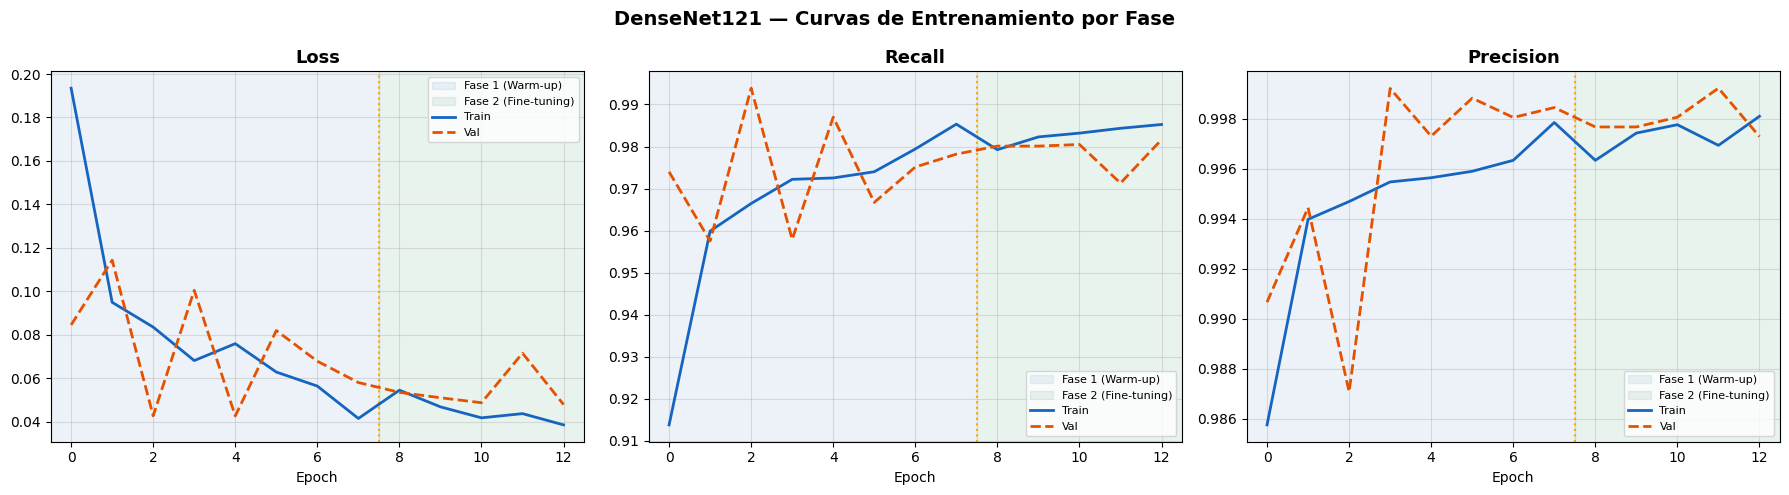

Figura guardada en: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/densenet121/plots/training_curves.png

--- Evaluando DenseNet121 sobre test set ---
194/194 ━━━━━━━━━━━━━━━━━━━━ 145s 742ms/step

Classification Report:
              precision    recall  f1-score   support

     healthy       0.92      0.98      0.95       483
    diseased       1.00      0.98      0.99      2613

    accuracy                           0.98      3096
   macro avg       0.96      0.98      0.97      3096
weighted avg       0.98      0.98      0.98      3096



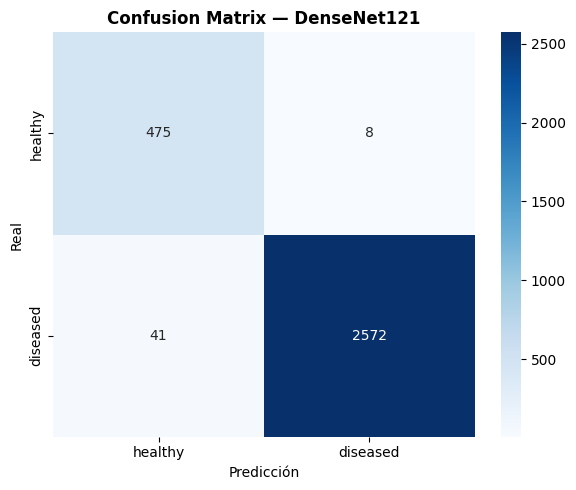


Resumen de métricas DenseNet121:
  accuracy                       0.9842
  precision_diseased             0.9969
  recall_diseased                0.9843
  f1_diseased                    0.9906
  precision_healthy              0.9205
  recall_healthy                 0.9834
  f1_healthy                     0.9510


In [52]:

# ============================================================
# CURVAS DE ENTRENAMIENTO (CON REGIONES DE FASE)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_list = [('loss', 'Loss'), ('recall', 'Recall'), ('precision', 'Precision')]
p1_len = len(history_dn_p1.history['loss'])
for ax, (metric, label) in zip(axes, metrics_list):
    if metric in history_dn_combined:
        n_total = len(history_dn_combined[metric])
        epochs  = range(n_total)
        # Sombrear región de cada fase
        ax.axvspan(-0.5, p1_len - 0.5,      alpha=0.10, color='steelblue', label='Fase 1 (Warm-up)')
        ax.axvspan(p1_len - 0.5, n_total - 0.5, alpha=0.10, color='seagreen',  label='Fase 2 (Fine-tuning)')
        ax.axvline(x=p1_len - 0.5, color='orange', linestyle=':', linewidth=1.5)
        ax.plot(epochs, history_dn_combined[metric],          label='Train', linewidth=2, color='#1565C0')
        ax.plot(epochs, history_dn_combined[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--', color='#E65100')
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_xlim(-0.5, n_total - 0.5)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)
plt.suptitle('DenseNet121 — Curvas de Entrenamiento por Fase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DENSENET_PLOTS / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {DENSENET_PLOTS / "training_curves.png"}')

# ============================================================
# EVALUACIÓN EN TEST SET
# ============================================================
dn_metrics = evaluate_model(
    model=densenet_model,
    test_gen=dn_test_gen,
    test_df=test_df,
    out_dir=DENSENET_DIR,
    model_name='DenseNet121'
)

print('\nResumen de métricas DenseNet121:')
for k, v in dn_metrics.items():
    print(f'  {k:<30} {v:.4f}')


## 13. Modelo ResNet50 — Warm-up

**Estrategia**: Entrenamiento en dos fases.

| Fase | Backbone | Learning Rate | Epochs |
|------|----------|--------------|--------|
| Fase 1 (Warm-up) | Congelado | 1e-3 | 8 |
| Fase 2 (Fine-tuning) | Últimas 50 capas desbloqueadas (BN congeladas) | 1e-5 | 15 |

**Arquitectura de la cabeza** (igual que DenseNet):
```
GlobalAveragePooling2D  →  Dense(128, relu)  →  Dropout(0.4)  →  Dense(1, sigmoid)
```

In [53]:
# ============================================================
# CONSTRUIR RESNET50
# ============================================================
def build_resnet50(img_size=IMG_SIZE, lr=WARMUP_LR):
    """ResNet50 — backbone congelado para Fase 1 (Warm-up)."""
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    base.trainable = False  # Congelado para Fase 1

    x = base.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dense(128, activation='relu', name='fc_128')(x)
    x = Dropout(0.4, name='dropout')(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=base.input, outputs=outputs, name='ResNet50_Warmup')

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            Precision(name='precision'),
            Recall(name='recall'),
            f1_metric,
        ]
    )
    return model


resnet_model = build_resnet50()

# Guardar summary
summary_path = RESNET_DIR / 'model_summary.txt'
with open(summary_path, 'w') as f:
    resnet_model.summary(print_fn=lambda x: f.write(x + '\n'))

print(f'Total params:     {resnet_model.count_params():,}')
trainable_params = sum(K.count_params(w) for w in resnet_model.trainable_weights)
print(f'Trainable params (Fase 1): {trainable_params:,}')
print(f'Summary guardado: {summary_path}')

Total params:     23,850,113
Trainable params (Fase 1): 262,401
Summary guardado: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/resnet50/model_summary.txt


## 14. ResNet50 — Fase 1: Backbone Congelado (Warm-up)

In [ ]:
# ============================================================
# CREAR GENERADORES RESNET50
# ============================================================
print('Creando generadores ResNet50...')
rn_train_gen, rn_val_gen, rn_test_gen = create_generators(
    train_df, val_df, test_df, resnet_preprocess
)
print(f'  Train batches: {len(rn_train_gen)}')
print()

# ============================================================
# FASE 1 — Solo entrenamos la cabeza
# ============================================================
rn_callbacks_p1 = get_callbacks(
    model_name='resnet50_phase1',
    out_dir=RESNET_DIR,
    monitor=MONITOR_METRIC,
    mode=MONITOR_MODE,
)

print('Iniciando Fase 1 — ResNet50 Warm-up (backbone congelado)...')
print(f'  Epochs:     {WARMUP_EPOCHS}')
print(f'  LR:         {WARMUP_LR}')
print(f'  Monitor:    {MONITOR_METRIC} ({MONITOR_MODE})')
print()

history_rn_p1 = resnet_model.fit(
    rn_train_gen,
    epochs=WARMUP_EPOCHS,
    validation_data=rn_val_gen,
    callbacks=rn_callbacks_p1,
    class_weight=class_weights,
    verbose=1,
)

print(f'\nFase 1 completada.')
print(f'Mejor val_recall Fase 1: {max(history_rn_p1.history[MONITOR_METRIC]):.4f}')

Creando generadores ResNet50...
Found 14446 validated image filenames.
Found 3096 validated image filenames.
Found 3096 validated image filenames.
  Train batches: 903

Iniciando Fase 1 — ResNet50 Warm-up (backbone congelado)...
  Epochs:     8
  LR:         0.001
  Monitor:    val_recall (max)

Epoch 1/8
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - f1_metric: 0.7354 - loss: 0.2462 - precision: 0.9810 - recall: 0.8984
Epoch 1: val_recall improved from None to 0.96096, saving model to /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/resnet50/resnet50_phase1_best.keras

Epoch 1: finished saving model to /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/results/resnet50/resnet50_phase1_best.keras
903/903 ━━━━━━━━━━━━━━━━━━━━ 728s 798ms/step - f1_metric: 0.7512 - loss: 0.1447 - precision: 0.9906 - recall: 0.9406 - val_f1_metric: 0.7588 - val_loss: 0.0827 - val_precision: 0.9992 - val_recall: 0.9610 - learning_rate: 0.0010
Epoch 2/8
903/903 ━━━━━

## 15. ResNet50 — Fase 2: Fine-tuning Parcial (últimas 50 capas)

In [ ]:
# ============================================================
# FASE 2 — Descongelar últimas N capas del backbone (BN siguen congeladas)
# ============================================================
# En TF 2.21 / Keras 3 las capas del backbone están aplanadas en el modelo.
# Las últimas 4 capas son la cabeza custom: global_avg_pool, fc_128, dropout, output.
HEAD_LAYERS_RN = 4
backbone_layers_rn = resnet_model.layers[:-HEAD_LAYERS_RN]

# Descongelar todas las capas del backbone primero
for layer in backbone_layers_rn:
    layer.trainable = True

# Recongelar las capas que NO son las últimas UNFREEZE_LAYERS del backbone
freeze_until = len(backbone_layers_rn) - UNFREEZE_LAYERS
for layer in backbone_layers_rn[:freeze_until]:
    layer.trainable = False

# Recongelar TODAS las BatchNormalization (mantener estadísticas de imagenet)
from tensorflow.keras.layers import BatchNormalization
for layer in resnet_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# Recompilar con LR bajo
resnet_model.compile(
    optimizer=Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=[
        Precision(name='precision'),
        Recall(name='recall'),
        f1_metric,
    ]
)

trainable_after = sum(K.count_params(w) for w in resnet_model.trainable_weights)
total_backbone_rn = len(backbone_layers_rn)
print(f'Total capas backbone: {total_backbone_rn}')
print(f'Trainable params (Fase 2): {trainable_after:,}')
print(f'Capas descongeladas: últimas {UNFREEZE_LAYERS} de {total_backbone_rn} (excluyendo BatchNorm)')
print()

rn_callbacks_p2 = get_callbacks(
    model_name='resnet50_phase2',
    out_dir=RESNET_DIR,
    monitor=MONITOR_METRIC,
    mode=MONITOR_MODE,
)

print('Iniciando Fase 2 — ResNet50 Fine-tuning parcial...')
print(f'  Epochs:     {FINETUNE_EPOCHS}')
print(f'  LR:         {FINETUNE_LR}')
print(f'  Monitor:    {MONITOR_METRIC} ({MONITOR_MODE})')
print()

history_rn_p2 = resnet_model.fit(
    rn_train_gen,
    epochs=FINETUNE_EPOCHS,
    validation_data=rn_val_gen,
    callbacks=rn_callbacks_p2,
    class_weight=class_weights,
    verbose=1,
)

# Combinar historiales
history_rn_combined = combine_histories(history_rn_p1, history_rn_p2)
history_rn_df = pd.DataFrame(history_rn_combined)
history_rn_df.to_csv(RESNET_DIR / 'history.csv', index_label='epoch')

print(f'\nHistorial combinado guardado en: {RESNET_DIR / "history.csv"}')
print(f'Mejor val_recall Fase 2: {max(history_rn_p2.history[MONITOR_METRIC]):.4f}')

## 16. Evaluación ResNet50

In [ ]:
# ============================================================
# CURVAS DE ENTRENAMIENTO (COMBINADAS CON LÍNEA DE FASE)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_list = [('loss', 'Loss'), ('recall', 'Recall'), ('precision', 'Precision')]
for ax, (metric, label) in zip(axes, metrics_list):
    if metric in history_rn_combined:
        epochs = range(len(history_rn_combined[metric]))
        ax.plot(epochs, history_rn_combined[metric],      label='Train', linewidth=2)
        ax.plot(epochs, history_rn_combined[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
        ax.axvline(x=len(history_rn_p1.history[metric]) - 1,
                   color='orange', linestyle=':', linewidth=2, label='Fin Fase 1')
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.4)
plt.suptitle('ResNet50 — Warm-up: Fases 1 y 2 (línea = cambio de fase)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESNET_PLOTS / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {RESNET_PLOTS / "training_curves.png"}')

# ============================================================
# EVALUACIÓN EN TEST SET
# ============================================================
rn_metrics = evaluate_model(
    model=resnet_model,
    test_gen=rn_test_gen,
    test_df=test_df,
    out_dir=RESNET_DIR,
    model_name='ResNet50'
)

print('\nResumen de métricas ResNet50:')
for k, v in rn_metrics.items():
    print(f'  {k:<30} {v:.4f}')

## 17. Guardado de Resultados

In [ ]:
# ============================================================
# LISTAR TODOS LOS ARCHIVOS GENERADOS
# ============================================================
print('Archivos generados en reports/results/\n')
for f in sorted(RESULTS_DIR.rglob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        rel = f.relative_to(RESULTS_DIR)
        print(f'  {str(rel):<60} ({size_kb:.1f} KB)')

## 18. Comparación Final

In [ ]:
# ============================================================
# TABLA COMPARATIVA
# ============================================================
comparison = pd.DataFrame([
    {
        'Model':              'DenseNet121',
        'Strategy':           'Warm-up (2 fases)',
        'accuracy':           dn_metrics['accuracy'],
        'recall_diseased':    dn_metrics['recall_diseased'],
        'precision_diseased': dn_metrics['precision_diseased'],
        'f1_diseased':        dn_metrics['f1_diseased'],
        'recall_healthy':     dn_metrics['recall_healthy'],
        'f1_healthy':         dn_metrics['f1_healthy'],
    },
    {
        'Model':              'ResNet50',
        'Strategy':           'Warm-up (2 fases)',
        'accuracy':           rn_metrics['accuracy'],
        'recall_diseased':    rn_metrics['recall_diseased'],
        'precision_diseased': rn_metrics['precision_diseased'],
        'f1_diseased':        rn_metrics['f1_diseased'],
        'recall_healthy':     rn_metrics['recall_healthy'],
        'f1_healthy':         rn_metrics['f1_healthy'],
    },
])

comparison = comparison.sort_values('recall_diseased', ascending=False).reset_index(drop=True)
comparison.to_csv(RESULTS_DIR / 'comparison.csv', index=False)
print('Tabla comparativa (ordenada por recall_diseased):')
display(comparison.style.highlight_max(axis=0, subset=['accuracy', 'recall_diseased',
                                                         'precision_diseased', 'f1_diseased']))

# ============================================================
# GRÁFICO COMPARATIVO
# ============================================================
metrics_to_plot = ['accuracy', 'recall_diseased', 'precision_diseased', 'f1_diseased']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, comparison.iloc[0][metrics_to_plot].values,
               width, label=f'{comparison.iloc[0]["Model"]} ({comparison.iloc[0]["Strategy"]})',
               color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison.iloc[1][metrics_to_plot].values,
               width, label=f'{comparison.iloc[1]["Model"]} ({comparison.iloc[1]["Strategy"]})',
               color='#F57F17', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Recall\n(diseased)', 'Precision\n(diseased)', 'F1\n(diseased)'],
                   fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación de Modelos — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Comparación guardada en: {RESULTS_DIR / "model_comparison.png"}')

## 19. Conclusiones

### Resultados

| Modelo | Estrategia | Recall (diseased) | F1 (diseased) |
|--------|-----------|------------------|--------------|
| DenseNet121 | Warm-up (2 fases) | Ver tabla arriba | Ver tabla arriba |
| ResNet50 | Warm-up (2 fases) | Ver tabla arriba | Ver tabla arriba |

### Observaciones

- La **métrica prioritaria es el recall** sobre la clase `diseased` para minimizar falsos negativos (enfermedades no detectadas).
- El uso de **class weights balanceados** permite compensar el desbalance natural del dataset.
- Ambos modelos usan la estrategia **Warm-up en 2 fases**: primero se entrena solo la cabeza con backbone congelado, luego se descongelan las últimas capas para fine-tuning con un learning rate bajo.
- La estrategia **Warm-up de DenseNet121** desbloquea las últimas 40 capas en Fase 2, mientras que **ResNet50** desbloquea las últimas 50.
- Las capas de **BatchNormalization** permanecen congeladas en ambos modelos durante Fase 2 para preservar las estadísticas aprendidas de ImageNet.

### Archivos Generados

```
reports/results/
├── sample_images.png
├── comparison.csv
├── model_comparison.png
├── densenet121/
│   ├── model_summary.txt
│   ├── history.csv
│   ├── classification_report.csv
│   ├── confusion_matrix.csv
│   ├── metrics.csv
│   └── plots/
│       ├── training_curves.png
│       └── confusion_matrix.png
└── resnet50/
    ├── model_summary.txt
    ├── history.csv
    ├── classification_report.csv
    ├── confusion_matrix.csv
    ├── metrics.csv
    └── plots/
        ├── training_curves.png
        └── confusion_matrix.png
```